# Exploratory Data Analysis - BTC Price and Media

### Objective
Assess whether media activity and tone add useful signal on top of BTC market features for crash prediction.

### Target Definition
A positive target corresponds to a bearish reversal event already defined in the BTC price dataset.

### EDA Focus
1. Check dataset alignment between price and media data
2. Merge both sources at the daily level
3. Measure linear, monotonic, and non-linear dependencies with the target
4. Build a compact feature set for benchmarking

### Goal
Determine whether media-derived variables bring complementary information beyond market momentum, volatility, and drawdown.


In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import StandardScaler
from pipelines.ml_benchmark import run_benchmark_pipeline

In [44]:
df_btc_price = pd.read_csv("../data/gold/market/btc_usdt_1d_features.csv")
df_btc_media = pd.read_csv("../data/gold/market_media_all_coins.csv")

# Keep only Bitcoin rows from the multi-coin media file
df_btc_media = df_btc_media[df_btc_media["crypto"].str.lower() == "bitcoin"].copy()
df_btc_media = df_btc_media.rename(columns={"day": "date"})
df_btc_media = df_btc_media[["date", "article_count", "avg_tone"]]


### 1. Initial Data Overview


In [45]:
df_btc_media.head()

,date,article_count,avg_tone
0,2608-07-15,688,-0.575917
6,2608-07-16,1985,-0.836241
11,2608-07-17,1697,0.163970
17,2608-07-18,2107,0.304992
23,2608-07-19,1652,-0.240413


In [46]:
print(f"{df_btc_price.shape[0]} rows and {df_btc_price.shape[1]} columns in the price dataset.")
print(f"{df_btc_media.shape[0]} rows and {df_btc_media.shape[1]} columns in the media dataset.")


3115 rows and 30 columns in the price dataset.
158 rows and 3 columns in the media dataset.


**Observation:**
The new media source contains multiple coins and fewer columns, so the notebook first filters `bitcoin` and then recreates the derived media features used later in the analysis.

**Impact:**
This keeps the workflow compatible with the benchmark, but the merge still requires overlapping dates between the BTC price series and the filtered Bitcoin media series.


In [47]:
df_btc_price[df_btc_price["open_time"] == df_btc_price["open_time"].min()]

,open_time,open,high,low,close,volume,quote_asset_volume,number_of_trades,taker_buy_base_volume,taker_buy_quote_volume,...,lag_volume_norm,lag_buy_pressure,momentum_acc,volatility_ratio,momentum_volatility,pressure_x_return,ma_7,ma_30,ma_ratio,target
0,2017-09-16,3674.01,3950.0,3470.66,3714.95,1297.563953,4.804878e+06,8809,624.887842,2.314536e+06,...,2.390714,0.4907,-0.156191,1.727747,-0.013297,0.001946,3864.46,4239.663667,0.911502,1


### 2. Time Alignment and Daily Aggregation

The notebook now loads the reduced multi-coin media file, filters `bitcoin`, and keeps only the two raw media variables `article_count` and `avg_tone` before alignment with BTC prices.


In [48]:
df_btc_media = df_btc_media[df_btc_media["date"] >= df_btc_price["open_time"].min()]
print(f"After filtering, {df_btc_media.shape[0]} rows remain in the media dataset.")
df_btc_media = df_btc_media[df_btc_media["date"] <= df_btc_price["open_time"].max()]
print(f"After filtering, {df_btc_media.shape[0]} rows remain in the media dataset.")

After filtering, 158 rows remain in the media dataset.
After filtering, 0 rows remain in the media dataset.


In [49]:
# Reload raw datasets in this cell to avoid stale notebook state.
df_btc_price = pd.read_csv("../data/gold/market/btc_usdt_1d_features.csv")
df_btc_media = pd.read_csv("../data/gold/market_media_all_coins.csv")

df_btc_media = df_btc_media[df_btc_media["crypto"].str.lower() == "bitcoin"].copy()
df_btc_media = df_btc_media.rename(columns={"day": "date"})
df_btc_media = df_btc_media[["date", "article_count", "avg_tone"]]


def convert_media_dates_with_best_offset(raw_dates, min_price_date, max_price_date):
    candidates = [0, 543, 591]
    best_offset = None
    best_dates = None
    best_overlap = -1
    best_valid = -1

    for offset in candidates:
        parsed = []
        for value in raw_dates:
            if pd.isna(value):
                parsed.append(pd.NaT)
                continue

            s = str(value).strip()
            parts = s.split("-")
            if len(parts) != 3:
                parsed.append(pd.NaT)
                continue

            year_str, month, day = parts
            try:
                year = int(year_str) - offset
            except ValueError:
                parsed.append(pd.NaT)
                continue

            parsed.append(pd.to_datetime(f"{year:04d}-{month}-{day}", errors="coerce"))

        parsed = pd.Series(parsed)
        valid = parsed.notna().sum()
        overlap = ((parsed >= min_price_date) & (parsed <= max_price_date)).sum()

        if overlap > best_overlap or (overlap == best_overlap and valid > best_valid):
            best_offset = offset
            best_dates = parsed
            best_overlap = overlap
            best_valid = valid

    return best_dates, best_offset, best_valid, best_overlap


# Parse BTC price dates first to score media date conversions against the real modeling window.
df_btc_price["open_time"] = pd.to_datetime(df_btc_price["open_time"], errors="coerce")
min_price_date = df_btc_price["open_time"].min()
max_price_date = df_btc_price["open_time"].max()

df_btc_media["date"], chosen_offset, valid_dates, overlap_dates = convert_media_dates_with_best_offset(
    df_btc_media["date"],
    min_price_date,
    max_price_date,
)

invalid_dates = df_btc_media["date"].isna().sum()
print(f"Chosen year offset for media dates: {chosen_offset}")
print(f"Valid media dates after parsing: {valid_dates}")
print(f"Overlapping media dates with BTC price range: {overlap_dates}")
print(f"Invalid media dates after parsing: {invalid_dates}")

df_btc_media = (
    df_btc_media
    .dropna(subset=["date"])
    .sort_values("date")
    .drop_duplicates("date", keep="last")
    .reset_index(drop=True)
)

if df_btc_media.empty:
    raise ValueError(
        "The Bitcoin media dataset is empty after date parsing. "
        "The `day` column in market_media_all_coins.csv could not be converted to supported calendar dates."
    )

min_media_date = df_btc_media["date"].min()
max_media_date = df_btc_media["date"].max()

print(f"BTC price range: {min_price_date.date()} to {max_price_date.date()}")
print(f"BTC media range: {min_media_date.date()} to {max_media_date.date()}")

df_btc_media = df_btc_media[
    (df_btc_media["date"] >= min_price_date) &
    (df_btc_media["date"] <= max_price_date)
].copy()
print(f"After filtering to the BTC price range, {df_btc_media.shape[0]} rows remain in the media dataset.")

if df_btc_media.empty:
    raise ValueError(
        f"No overlapping dates between BTC price data ({min_price_date.date()} to {max_price_date.date()}) "
        f"and media data ({min_media_date.date()} to {max_media_date.date()}). "
        "Check the date calendar or source period in market_media_all_coins.csv before merging."
    )

original_dates = set(df_btc_media["date"])

df_btc_media = (
    df_btc_media
    .set_index("date")
    .reindex(df_btc_price["open_time"])
    .rename_axis("date")
    .reset_index()
)

cols_to_fill = ["avg_tone", "article_count"]
df_btc_media["was_added"] = ~df_btc_media["date"].isin(original_dates)
df_btc_media[cols_to_fill] = df_btc_media[cols_to_fill].fillna(0)

print(f"After reindexing, {df_btc_media.shape[0]} rows remain in the media dataset.")
df_added = df_btc_media[df_btc_media["was_added"]]
print(f"{df_added.shape[0]} rows were added by reindexing.")
df_added.head()


Chosen year offset for media dates: 591
Valid media dates after parsing: 158
Overlapping media dates with BTC price range: 146
Invalid media dates after parsing: 131
BTC price range: 2017-09-16 to 2026-03-27
BTC media range: 2017-07-15 to 2020-09-26
After filtering to the BTC price range, 24 rows remain in the media dataset.
After reindexing, 3115 rows remain in the media dataset.
3091 rows were added by reindexing.


,date,article_count,avg_tone,was_added
0,2017-09-16,0.0,0.0,True
1,2017-09-17,0.0,0.0,True
2,2017-09-18,0.0,0.0,True
3,2017-09-19,0.0,0.0,True
4,2017-09-20,0.0,0.0,True


**Observation:**
With the reduced file, feature engineering now happens inside the notebook before reindexing and merging.

**Conclusion:**
If the date ranges overlap, the rest of the analysis remains valid with the new source. If they do not, the notebook now fails early with a clear error instead of silently producing a broken merge.


### 3. Merged BTC + Media Dataset


In [50]:
df_btc_media_and_price = pd.merge(df_btc_price, df_btc_media, left_on="open_time", right_on="date", how="inner")
df_btc_media_and_price.head()
df_btc_media_and_price.columns
df_btc_media_and_price.drop(columns=["open_time", "date", "was_added"], inplace=True)

**Observations:**
- The merged dataset combines BTC market variables with only two raw media features: `article_count` and `avg_tone`.
- `article_count` captures media attention volume, while `avg_tone` captures the average sentiment signal.
- No rolling or lagged media features are kept in order to test the pure incremental value of the raw media enrichment.

**Conclusion:**
The merged table is now focused on a minimal media enrichment setting, which makes the benchmark easier to interpret.


### 4. Correlation Between Features and Target

**Objective**
Compare market and media variables using three views:
- Pearson for linear effects
- Spearman for monotonic effects
- Mutual Information for non-linear dependencies


**Pearson Correlation with Target**


/tmp/ipykernel_245106/571131851.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=corrs_pearson.index, y=corrs_pearson.values, palette=colors)


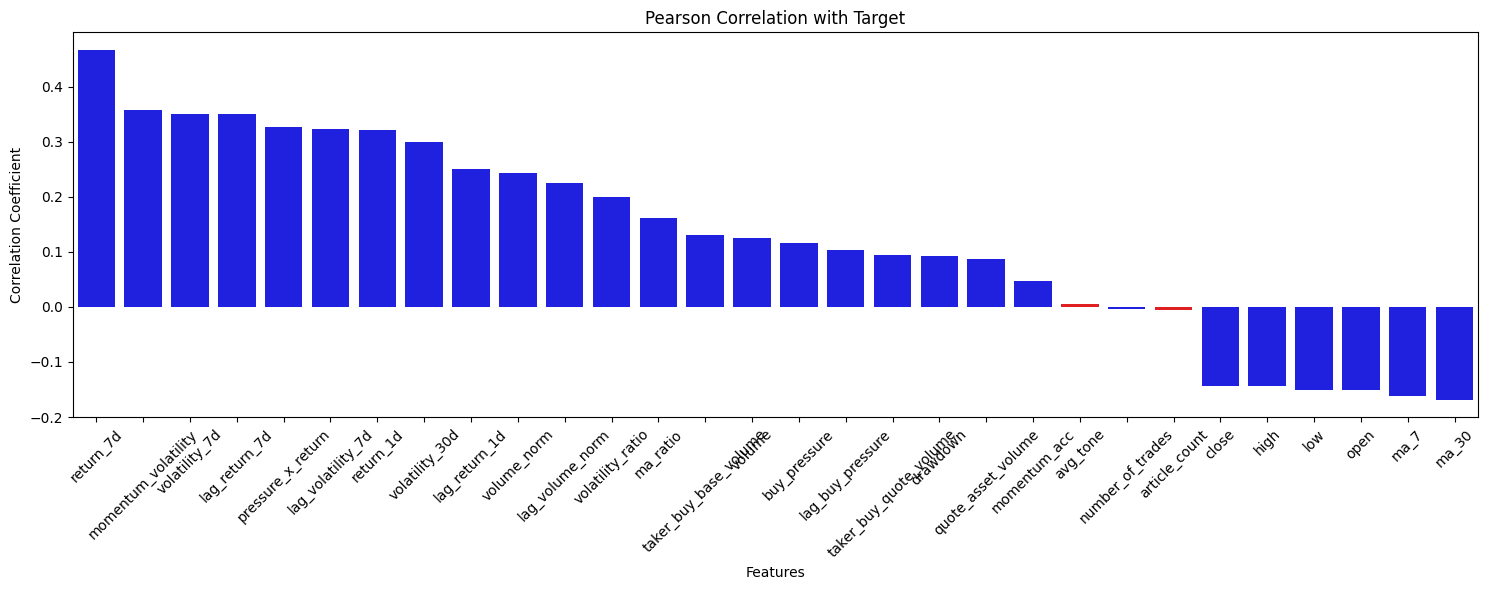

In [51]:
# Pearson correlation with target
corrs_pearson = (
    df_btc_media_and_price
    .corr(method="pearson")["target"]
    .sort_values(ascending=False)
    .drop("target")
)

media_cols = ["avg_tone", "article_count"]
colors = ["red" if col in media_cols else "blue" for col in corrs_pearson.index]

plt.figure(figsize=(15, 6))
sns.barplot(x=corrs_pearson.index, y=corrs_pearson.values, palette=colors)
plt.xticks(rotation=45)
plt.title("Pearson Correlation with Target")
plt.ylabel("Correlation Coefficient")
plt.xlabel("Features")
plt.tight_layout()
plt.show()


**Observations:**
- Market features remain dominant, especially `return_7d`, `momentum_volatility`, and short-term volatility.
- Among the two raw media variables, `article_count` is expected to be more informative than `avg_tone`.
- `avg_tone` should be interpreted as a weak complementary signal rather than a primary driver.

**Conclusion:**
In this minimal setup, media enrichment is intentionally lightweight: the key question is whether raw attention and raw tone improve the market-only baseline.


**Spearman Correlation with Target**


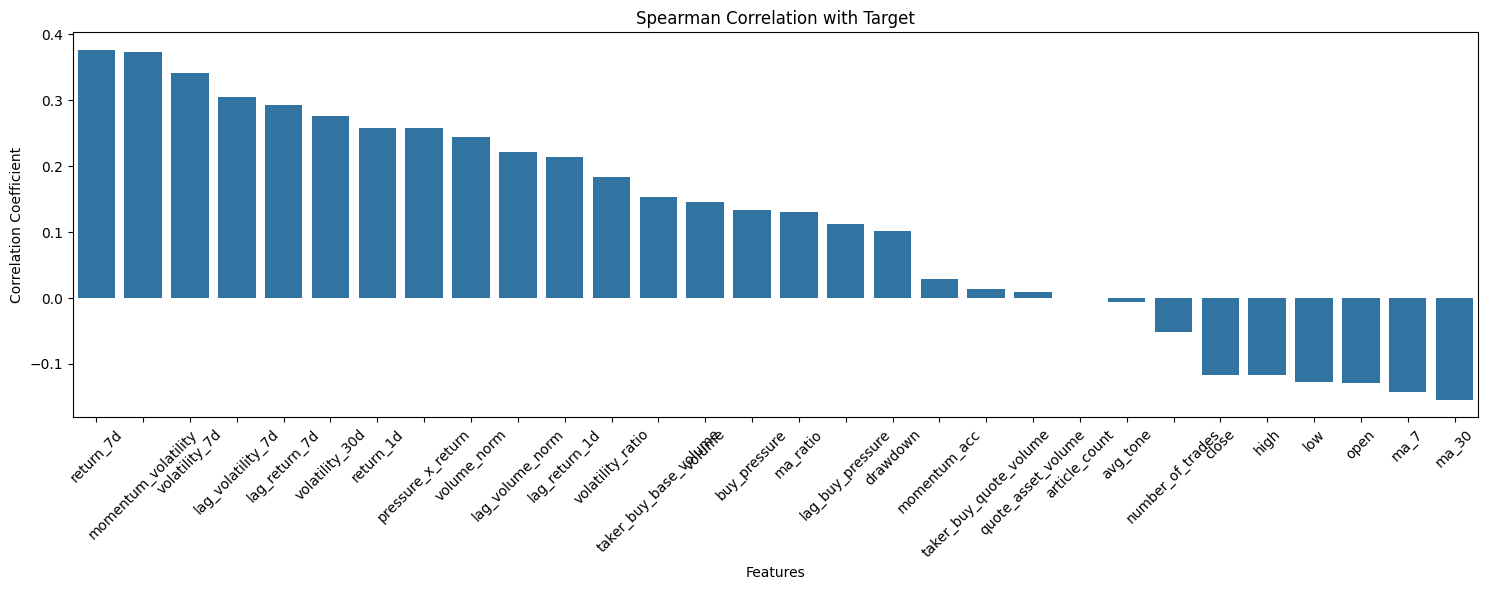

In [52]:
# Spearman correlation with target
corrs_spearman= df_btc_media_and_price.corr(method="spearman")["target"].sort_values(ascending=False).drop("target")
plt.figure(figsize=(15, 6))
sns.barplot(x=corrs_spearman.index, y=corrs_spearman.values)
plt.xticks(rotation=45)
plt.title("Spearman Correlation with Target")
plt.ylabel("Correlation Coefficient")
plt.xlabel("Features")
plt.tight_layout()
plt.show()


**Observations:**
- The ranking should remain mostly driven by market variables.
- `article_count` may still retain a monotonic relationship with crash risk if media attention rises around stressed market regimes.
- `avg_tone` is likely to remain weaker and less stable than activity-based media information.

**Conclusion:**
Using only raw media variables makes the monotonic analysis easier to read, even if the media contribution is modest.


**Mutual Information with Target**


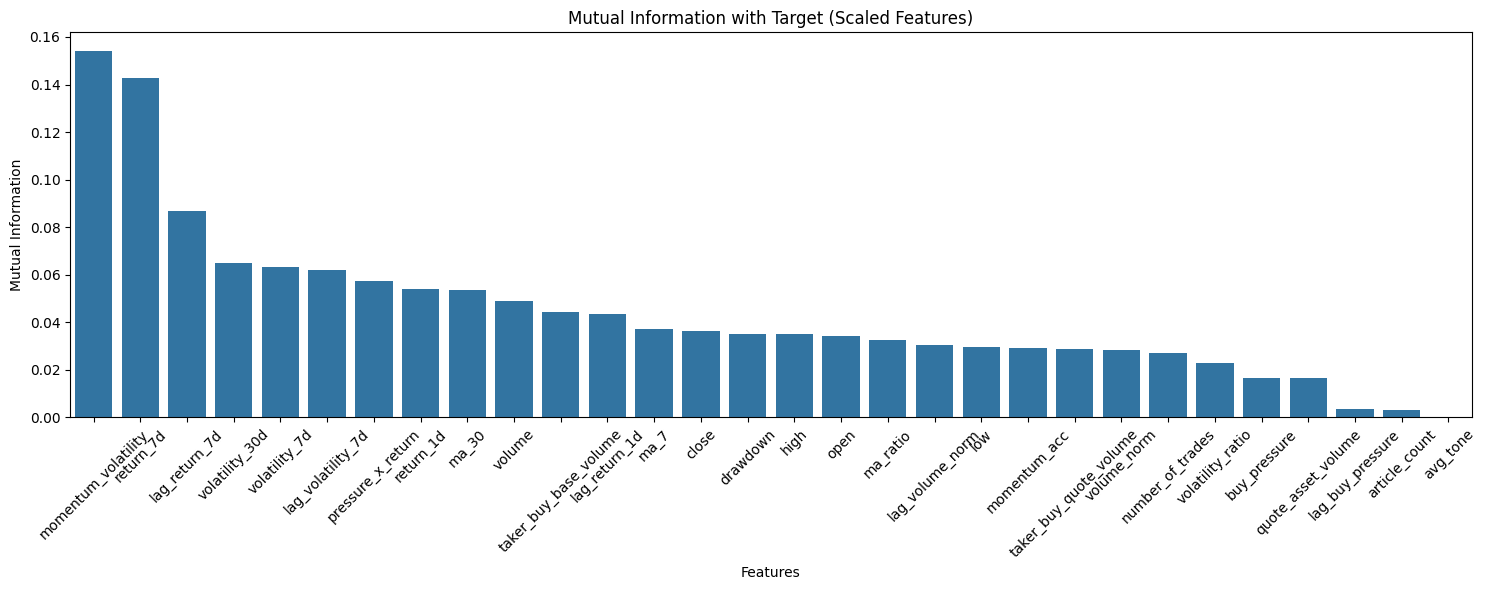

momentum_volatility       0.154246
return_7d                 0.142694
lag_return_7d             0.087018
volatility_30d            0.064804
volatility_7d             0.063392
lag_volatility_7d         0.062044
pressure_x_return         0.057443
return_1d                 0.053969
ma_30                     0.053627
volume                    0.049171
taker_buy_base_volume     0.044229
lag_return_1d             0.043666
ma_7                      0.037237
close                     0.036364
drawdown                  0.035286
high                      0.035169
open                      0.034140
ma_ratio                  0.032367
lag_volume_norm           0.030564
low                       0.029490
momentum_acc              0.029023
taker_buy_quote_volume    0.028761
volume_norm               0.028164
number_of_trades          0.026972
volatility_ratio          0.022860
buy_pressure              0.016566
quote_asset_volume        0.016518
lag_buy_pressure          0.003514
article_count       

In [53]:
X = df_btc_media_and_price.drop(columns=["target"])
y = df_btc_media_and_price["target"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

mutual_info = mutual_info_classif(
    X_scaled,
    y,
    discrete_features=False,
    n_neighbors=5,
    random_state=42
)

mutual_info_series = pd.Series(mutual_info, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(15, 6))
sns.barplot(x=mutual_info_series.index, y=mutual_info_series.values)
plt.xticks(rotation=45)
plt.title("Mutual Information with Target (Scaled Features)")
plt.ylabel("Mutual Information")
plt.xlabel("Features")
plt.tight_layout()
plt.show()

mutual_info_series

**Observations:**
- Non-linear dependence is still expected to favor market variables over media variables.
- `article_count` is the raw media feature most likely to add complementary information.
- `avg_tone` may still contain weak non-linear signal, but its standalone contribution should remain limited.

**Conclusion:**
The raw-media version of the notebook is designed to test a simple enrichment hypothesis rather than maximize media feature engineering.


### 5. Final Dataset for Modeling


In [54]:
df_btc_media_and_price = pd.merge(df_btc_price, df_btc_media, left_on="open_time", right_on="date", how="inner")
df_btc_media_and_price.head()
df_btc_media_and_price.columns
df_btc_media_and_price.drop(columns=["open_time", "date"], inplace=True)

In [55]:
df_btc_media.columns

Index(['date', 'article_count', 'avg_tone', 'was_added'], dtype='str')

**Feature Selection Rationale**

The selected subset keeps the strongest market signals and only two media variables:
- `article_count`
- `avg_tone`

This makes the benchmark stricter: any performance gain can be attributed to raw media enrichment rather than engineered media features.


In [56]:
SELECTED_FEATURES = [
    # Momentum
    "return_1d", "return_7d",

    # Volatility
    "volatility_7d", "volatility_30d",

    # Market behavior
    "buy_pressure",

    # Risk
    "drawdown",

    # Trend
    "ma_ratio",

    # Lags
    "lag_return_1d", "lag_return_7d",
    "lag_volatility_7d",
    "lag_buy_pressure",
    "lag_volume_norm",

    # Additional
    "momentum_acc",
    "momentum_volatility",
    "volume",
    "number_of_trades",
    "quote_asset_volume",

    # Raw media enrichment
    "avg_tone",
    "article_count",
]

TARGET = "target"

df_btc_media_and_price = df_btc_media_and_price[SELECTED_FEATURES + [TARGET]]
df_btc_media_and_price.head()


,return_1d,return_7d,volatility_7d,volatility_30d,buy_pressure,drawdown,ma_ratio,lag_return_1d,lag_return_7d,lag_volatility_7d,lag_buy_pressure,lag_volume_norm,momentum_acc,momentum_volatility,volume,number_of_trades,quote_asset_volume,avg_tone,article_count,target
0,0.004041,-0.127702,0.104128,0.060268,0.481585,-0.231640,0.911502,0.160231,-0.136079,0.103904,0.490700,2.390714,-0.156191,-0.013297,1297.563953,8809,4.804878e+06,0.0,0.0,1
1,-0.004027,-0.104199,0.103943,0.059834,0.401559,-0.234734,0.899889,0.004041,-0.127702,0.104128,0.481585,1.544177,-0.008068,-0.010831,682.171210,6355,2.466490e+06,0.0,0.0,1
2,0.090546,-0.041217,0.110665,0.062149,0.405472,-0.165443,0.894766,-0.004027,-0.104199,0.103943,0.401559,0.828846,0.094573,-0.004561,1030.006455,8220,4.069033e+06,0.0,0.0,1
3,-0.030971,-0.060926,0.111239,0.062376,0.285173,-0.191290,0.887418,0.090546,-0.041217,0.110665,0.405472,1.219432,-0.121518,-0.006777,902.332129,7342,3.558315e+06,0.0,0.0,1
4,-0.002568,-0.011329,0.109144,0.062290,0.548281,-0.193367,0.886718,-0.030971,-0.060926,0.111239,0.285173,1.050238,0.028404,-0.001237,720.935076,7231,2.839584e+06,0.0,0.0,0


**Observations:**
- The final feature set remains centered on market structure: momentum, volatility, drawdown, and lag features.
- Media enrichment is deliberately minimal and includes only `article_count` and `avg_tone`.
- This setup is useful for testing whether simple media information improves prediction without extra media feature engineering.

**Conclusion:**
This selection keeps the interpretation clean: if performance improves, the gain comes from raw media enrichment rather than engineered tone dynamics.


In [57]:
df_btc_media_and_price.isna().sum()

return_1d              0
return_7d              0
volatility_7d          0
volatility_30d         0
buy_pressure           0
drawdown               0
ma_ratio               0
lag_return_1d          0
lag_return_7d          0
lag_volatility_7d      0
lag_buy_pressure       0
lag_volume_norm        0
momentum_acc           0
momentum_volatility    0
volume                 0
number_of_trades       0
quote_asset_volume     0
avg_tone               0
article_count          0
target                 0
dtype: int64